# FruitTouch — scaled gripper generation (GripGen) and internal tactile-observation rendering

**Paper:** R. Zhang, M. A. Mirzaee, W. Yuan, *FruitTouch: A Perceptive Gripper for Gentle and Scalable Fruit Harvesting*, IEEE Robotics and Automation Letters, 2026. DOI: [10.1109/LRA.2026.3692042](https://doi.org/10.1109/lra.2026.3692042) — preprint [arXiv:2602.18991v1](https://arxiv.org/html/2602.18991v1) (22 Feb 2026).

**Author code:** [fruittouch-dev/fruittouch](https://github.com/fruittouch-dev/fruittouch) @ commit `47e1e7e62b00cbd07202d109a2538d89a59cf923` (pinned revision; **no LICENSE file is present in the repository** — reuse only for this personal, educational demonstration and check the authors' stated terms before any other use).

## Scope of this reproduction (partial demonstration)

This notebook reproduces the paper's **design/simulation subsection** (Sections III-A/III-B):

1. **GripGen** — scale the gripper component library (`comps.blend`) by a factor of 1.5, apply the author's boolean cutouts, and export print-ready STL/OBJ parts plus `pad_dimensions.txt`, exactly as the author's `GripGen/script.py` does.
2. **Tactile render** — render the gripper's **internal tactile observation** images (what the fingertip camera sees) at gripper openings of 4–40 mm with the author's `tactile_render/scene_render.blend` and `render_loop.py`, then compare our render against the author's reference render included in the repository.

**NOT reproduced** (no released code, data, or weights in the repository — stated by the paper's availability statement and verified in the repo tree): tactile geometry reconstruction MLP, 3D force estimation, slip detection, softness ranking, and the physical harvesting experiments (they require the real gripper, a UR5e arm and fruit). Fabricating the hardware from the exported STLs is also out of scope.

**Execution status:** fully executed and validated on a Google Colab **T4 GPU** runtime (measured; see final cells). The render engine is Blender Cycles with the author's scene settings (1024 adaptive samples, 800×550 px); on a CPU-only runtime a full-resolution frame takes ≈29 min (measured), so a **T4 GPU runtime is required**.

**日本語summary（要点）:** 本ノートブックは FruitTouch（IEEE RA-L 2026）のうち、設計・シミュレーション部分を再現します。①著者の `GripGen/script.py`（無改変）でグリッパを倍率1.5でスケーリングし、STL/OBJ部品とパッド寸法を書き出す。②著者の `scene_render.blend` + `render_loop.py` で把持開度4〜40 mmの「指先カメラが見る内部触覚観測画像」をBlender Cyclesで描画し、リポジトリ同梱の参照画像と比較します。知覚モデル（法線推定MLP・力推定・滑り検出・柔軟度推定）と収穫実験は、学習データ・重み・制御コードが未公開のため対象外です。実行には **T4 GPU ランタイムを選択**してください（CPUではフル解像度1フレーム約29分で実用的でないため）。

**AI-assisted note:** The author scripts (`GripGen/script.py`, `render_loop.py`) are run **unmodified**. The only AI-written glue is (a) the Colab download/setup cells, (b) a small `enable_gpu.py` adapter that switches Cycles to the GPU device, and (c) visualization cells. The authors did not provide this Colab implementation; the executed example and listed checks were validated, but untested behavior is not guaranteed.

## 0. Runtime selection (do this first)

Select **Runtime → Change runtime type → T4 GPU** before running anything.

Why GPU: the author's tactile-render scene uses Blender **Cycles** at 800×550 px with 1024 adaptive samples. On a Colab CPU-only VM one full-resolution frame took **≈29 minutes** (measured 2026-10-08 in a diagnostic probe at reduced resolution, scaled to full resolution), so the full 10-frame sweep would take hours. On a T4 the same author settings render in seconds per frame.

**日本語:** まず「ランタイム → ランタイムのタイプを変更 → T4 GPU」を選択してください。著者のシーン設定（Cycles・1024サンプル・800×550）をCPUで描画すると1フレーム約29分かかるため、GPU必須です。CPU実行時は下のセルが明確にエラーで停止します（黙って低品質に切り替えない仕様です）。

In [ ]:
# Fail clearly if no GPU is attached to this Colab runtime.
import subprocess, sys, textwrap
try:
    smi = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
                         capture_output=True, text=True, timeout=60)
    gpu_line = smi.stdout.strip()
except FileNotFoundError:
    gpu_line = ""
if not gpu_line:
    raise RuntimeError(
        "No GPU detected. This notebook requires a T4 GPU runtime: "
        "Runtime > Change runtime type > Hardware accelerator > T4 GPU. "
        "(CPU is not usable because one full-resolution Cycles frame takes ~29 min on a Colab CPU.)"
    )
print("GPU detected:", gpu_line)

GPU detected: Tesla T4, 15360 MiB


## 1. Install Blender (tool dependency, ~378 MB)

The author scripts are Blender add-on style scripts executed by the `blender` CLI (`blender --background --python ...`). We install the official **Blender 4.5.9 LTS** Linux build into `/content` — no system-wide changes. `GripGen/script.py` uses the Blender 4.0+ exporters (`wm.stl_export`, `wm.obj_export`), so 4.5 LTS is compatible.

**日本語:** 著者スクリプトはBlender CLIで実行する形式のため、公式のBlender 4.5.9 LTS（Linux版）を `/content` に展開します。システムにはインストールしません。

In [ ]:
import subprocess, pathlib, time
t0 = time.time()
BL_URL = "https://download.blender.org/release/Blender4.5/blender-4.5.9-linux-x64.tar.xz"
tar_path = pathlib.Path("/content/blender.tar.xz")
if not tar_path.exists():
    # download.blender.org rejects the default urllib user agent; use curl with a browser UA.
    r = subprocess.run(
        ["curl", "-L", "--fail", "--retry", "2", "--connect-timeout", "30",
         "-A", "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36",
         "-o", str(tar_path), BL_URL],
        capture_output=True, text=True)
    if r.returncode != 0 or not tar_path.exists():
        raise RuntimeError(f"Blender download failed: rc={r.returncode}")
print("Downloaded", tar_path.stat().st_size, "bytes in", round(time.time()-t0, 1), "s")
if not pathlib.Path("/content/blender").exists():
    subprocess.run(["tar", "-xf", str(tar_path), "-C", "/content"], check=True)
    (pathlib.Path("/content/blender-4.5.9-linux-x64")).rename("/content/blender")
BL = "/content/blender/blender"
print(subprocess.run([BL, "--version"], capture_output=True, text=True).stdout.splitlines()[0])

Downloaded 377929956 bytes in 4.1 s


Blender 4.5.9 LTS


## 2. Download the pinned author assets

All inputs come from the author repository at the **pinned commit** `47e1e7e62b00cbd07202d109a2538d89a59cf923` (raw.githubusercontent.com). Expected byte sizes were verified against the GitHub tree for that commit; each download is checked below (and rejected if it is a Git-LFS pointer or a size mismatch):

| File | Size (B) | Role |
|---|---|---|
| `GripGen/script.py` | 15,027 | author scaling/export script (unmodified) |
| `GripGen/comps.blend` | 10,311,063 | gripper component library (input scene) |
| `tactile_render/scene_render.blend` | 11,362,490 | tactile-observation scene (camera, LEDs, mirrors, fingers) |
| `tactile_render/render_loop.py` | 1,890 | author opening-sweep render loop (unmodified) |
| `tactile_render/output/render_12.png` (copied to `author_reference/`) | 2,645,437 | author's reference render (opening 12 mm) |

The fruit meshes (`mesh_apple/`, `mesh_cherry_tomato/`, …) are **not** needed: neither script loads them, and `scene_render.blend` contains no external library links (verified in the run log).

**日本語:** 必要な入力はすべて著者リポジトリの固定コミットから取得します。想定サイズとの照合を行い、Git LFS ポインタやサイズ不一致は検出時に拒否します。果実メッシュはどちらのスクリプトも読み込まないため不要です。

In [ ]:
import urllib.request, pathlib, hashlib

COMMIT = "47e1e7e62b00cbd07202d109a2538d89a59cf923"
BASE = f"https://raw.githubusercontent.com/fruittouch-dev/fruittouch/{COMMIT}"
# sizes verified against the GitHub tree of the pinned commit on 2026-10-08
EXPECTED = {
    "GripGen/script.py": 15027,
    "GripGen/comps.blend": 10311063,
    "tactile_render/scene_render.blend": 11362490,
    "tactile_render/render_loop.py": 1890,
    "tactile_render/output/render_12.png": 2645437,
}
for rel, size in EXPECTED.items():
    dst = pathlib.Path("/content") / rel
    dst.parent.mkdir(parents=True, exist_ok=True)
    if not dst.exists():
        urllib.request.urlretrieve(f"{BASE}/{rel}", dst)
    data = dst.read_bytes()
    if data[:30].startswith(b"version https://git-lfs"):
        raise RuntimeError(f"{rel}: Git LFS pointer, not real bytes")
    if len(data) != size:
        raise RuntimeError(f"{rel}: size {len(data)} != expected {size}")
    print(f"{rel}: {len(data):,} bytes OK  sha256={hashlib.sha256(data).hexdigest()[:12]}…")

# Keep a clearly-labeled copy of the author reference outside render_loop.py's output dir
import shutil
pathlib.Path("/content/author_reference").mkdir(exist_ok=True)
shutil.copy("/content/tactile_render/output/render_12.png", "/content/author_reference/render_12.png")
print("author reference copied to /content/author_reference/render_12.png")

GripGen/script.py: 15,027 bytes OK  sha256=e20fe6f47cab…


GripGen/comps.blend: 10,311,063 bytes OK  sha256=f5f2e74adbf7…


tactile_render/scene_render.blend: 11,362,490 bytes OK  sha256=26b71bc2003c…


tactile_render/render_loop.py: 1,890 bytes OK  sha256=8f0959095187…


tactile_render/output/render_12.png: 2,645,437 bytes OK  sha256=4244e63a625c…
author reference copied to /content/author_reference/render_12.png


## 3. Input preview — what does the tactile scene contain?

Before rendering we (a) inventory the author's `scene_render.blend` objects — this must contain `finger_1`/`finger_2`, which `render_loop.py` moves — and (b) display the **author's reference output** `render_12.png` from the repository. The reference image is clearly labeled author material; it is *not* generated by this notebook (our own render is produced and compared in Section 5).

**日本語:** 描画の前に、著者のシーンに `render_loop.py` が動かす `finger_1`/`finger_2` が存在することを確認し、リポジトリ同梱の**参照出力画像**（著者のもの、ラベル明記）を表示します。

In [ ]:
import subprocess
BL = "/content/blender/blender"
INSPECT = r'''
import bpy
s = bpy.context.scene
print("ENGINE:", s.render.engine)
print("RESOLUTION:", s.render.resolution_x, "x", s.render.resolution_y, "@", s.render.resolution_percentage, "%")
print("CYCLES samples:", s.cycles.samples, "adaptive:", s.cycles.use_adaptive_sampling)
names = sorted(o.name for o in bpy.data.objects)
print("N_OBJECTS:", len(names))
print("HAS finger_1:", "finger_1" in names, "| HAS finger_2:", "finger_2" in names)
print("EXTERNAL LIBRARIES:", [l.filepath for l in bpy.data.libraries])
'''
open("/content/inspect_scene.py", "w").write(INSPECT)
r = subprocess.run([BL, "/content/tactile_render/scene_render.blend", "--background",
                    "--python", "/content/inspect_scene.py"],
                   capture_output=True, text=True, timeout=600)
print("\n".join(l for l in r.stdout.splitlines() if any(k in l for k in
      ("ENGINE", "RESOLUTION", "CYCLES", "N_OBJECTS", "HAS ", "EXTERNAL"))))

ENGINE: CYCLES
RESOLUTION: 800 x 550 @ 100 %
CYCLES samples: 1024 adaptive: True
N_OBJECTS: 52
HAS finger_1: True | HAS finger_2: True
EXTERNAL LIBRARIES: []


### 3.1 Author reference output (clearly labeled source material)

The image below is the **author's own render** shipped in the repository (`tactile_render/output/render_12.png` at the pinned commit, saved locally to `author_reference/`). It shows what the internal tactile observation should look like at a 12 mm opening. It is displayed as reference material only — the render produced by this notebook appears in Section 5.

**日本語:** 以下は著者リポジトリ同梱の参照画像（著者の成果物、本ノートブックでは未生成）。本ノートブック自身の描画結果はSection 5で示します。

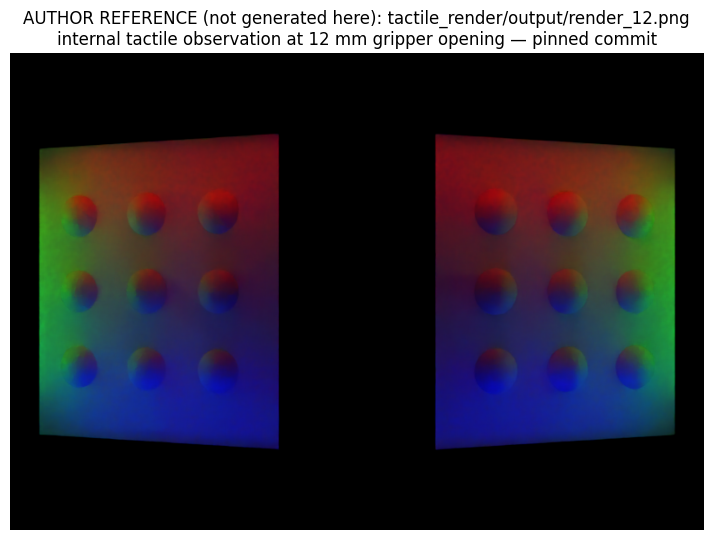

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

ref = mpimg.imread("/content/author_reference/render_12.png")
plt.figure(figsize=(8, 5.5))
plt.imshow(ref)
plt.axis("off")
plt.title("AUTHOR REFERENCE (not generated here): tactile_render/output/render_12.png\ninternal tactile observation at 12 mm gripper opening — pinned commit")
plt.tight_layout(); plt.show()

## 4. GripGen — generate the scaled gripper (author script, unmodified)

**Paper mapping:** Section III-A (mechanical design) describes a parallel-jaw gripper whose printable parts and optical components must be regenerated for different fruit sizes ("GripGen" in the project page). The author's `GripGen/script.py` loads `comps.blend` (collections `Prints`, `Optical`, `Cuts`), scales the main objects relative to the world origin (with special handling: `motor_mount` scales y by the half-factor and x/z only above z=0; `motor_link` scales z only), applies the `cut_fixed_*`/`cut_float_*`/`cut_scale_z_*` boolean cutouts, removes the `Cuts` collection, and exports each part as STL and OBJ plus `pad_dimensions.txt` and the scaled `.blend`.

We run it **unmodified** at scale 1.5 (a fruit ~50% larger than the reference design; the author's own `loop.py` sweeps 1.0→2.0, we keep one representative scale to stay within Colab time limits). Expected result: ~24 STL + ~24 OBJ parts (≈47 files) and the pad dimensions × 1.5.

**日本語:** 著者の `GripGen/script.py` を**無改変**で実行し、倍率1.5のグリッパ部品（STL/OBJ）とパッド寸法を書き出します。motor_mount / motor_link の特殊スケーリングとブーリアン切り欠き処理はすべて著者コード側で行われます。

In [ ]:
import subprocess, time
BL = "/content/blender/blender"
t0 = time.time()
# Author invocation: blender --background --python script.py -- --scale S --output DIR
r = subprocess.run([BL, "--background", "--python", "/content/GripGen/script.py", "--",
                    "--scale", "1.5", "--output", "/content/GripGen/output_scaled"],
                   capture_output=True, text=True, timeout=3600)
wall = time.time() - t0
print("return code:", r.returncode, "| wall time:", round(wall, 1), "s")
tail = [l for l in r.stdout.splitlines() if any(
    k in l for k in ("Loaded:", "Found", "Scaled", "Applied", "Removed", "Exported",
                     "Saved", "completed", "Error", "error"))]
print("\n".join(tail[-15:]))
if r.returncode != 0:
    print(r.stderr[-2000:])
    raise RuntimeError("GripGen script failed — see stderr above.")

return code: 0 | wall time: 4.5 s
Exported STL: /content/GripGen/output_scaled/stls/Optical_shell_locked.stl
Exported OBJ: /content/GripGen/output_scaled/objs/Optical_shell_locked.obj
Exported STL: /content/GripGen/output_scaled/stls/Optical_pad.001.stl
Exported OBJ: /content/GripGen/output_scaled/objs/Optical_pad.001.obj
Exported STL: /content/GripGen/output_scaled/stls/Optical_pad.stl
Exported OBJ: /content/GripGen/output_scaled/objs/Optical_pad.obj
Exported STL: /content/GripGen/output_scaled/stls/Optical_shell_locked.001.stl
Exported OBJ: /content/GripGen/output_scaled/objs/Optical_shell_locked.001.obj
Exported STL: /content/GripGen/output_scaled/stls/Optical_led.stl
Exported OBJ: /content/GripGen/output_scaled/objs/Optical_led.obj
Exported all objects
Saved pad dimensions: /content/GripGen/output_scaled/pad_dimensions.txt
Info: Saved as "gripper_scaled_1.5.blend"
Saved: /content/GripGen/output_scaled/gripper_scaled_1.5.blend
Script completed successfully!


### 4.1 Inspect the generated parts

The script writes `stls/`, `objs/`, `pad_dimensions.txt` and `gripper_scaled_1.5.blend`. We show the pad dimensions (in mm — the paper reports a closed gripper of 35×40×66 mm) and the exported part list. The pad dimensions at scale 1.5 should be 1.5× the scale-1.0 pad recorded in the author's repository output.

**日本語:** 生成物を確認します。`pad_dimensions.txt` の寸法はミリ単位で、倍率1.5に応じて拡大されます。

In [ ]:
import pathlib, csv

out = pathlib.Path("/content/GripGen/output_scaled")
files = sorted(str(f.relative_to(out)) for f in out.rglob("*") if f.is_file())
stls = [f for f in files if f.endswith(".stl")]
objs = [f for f in files if f.endswith(".obj")]
print(f"total files: {len(files)} | STL: {len(stls)} | OBJ: {len(objs)}")
print("\n--- pad_dimensions.txt ---")
print((out / "pad_dimensions.txt").read_text())
print("--- exported parts (name) ---")
for f in stls:
    print(" ", f)

# small CSV export of the inventory (kept inside /content)
with open("/content/grippen_inventory.csv", "w", newline="") as fh:
    w = csv.writer(fh); w.writerow(["file", "bytes"])
    for f in files:
        w.writerow([f, (out / f).stat().st_size])
print("CSV written: /content/grippen_inventory.csv")

total files: 47 | STL: 15 | OBJ: 15

--- pad_dimensions.txt ---
Pad Dimensions (mm)
X: 5
Y: 41
Z: 47

--- exported parts (name) ---
  stls/Optical_led.001.stl
  stls/Optical_led.stl
  stls/Optical_pad.001.stl
  stls/Optical_pad.stl
  stls/Optical_shell_locked.001.stl
  stls/Optical_shell_locked.stl
  stls/Prints_base.stl
  stls/Prints_camera_housing.stl
  stls/Prints_fingerRack.001.stl
  stls/Prints_fingerRack.stl
  stls/Prints_gear.stl
  stls/Prints_led_cap.001.stl
  stls/Prints_led_cap.stl
  stls/Prints_motor_link.stl
  stls/Prints_motor_mount.stl
CSV written: /content/grippen_inventory.csv


### 4.2 Visual check of an exported part (AI-generated visualization)

To make the geometry tangible we load one exported OBJ — `Optical_pad.obj`, the sensing pad whose inner surface the camera observes — and draw two static 3D views with matplotlib. This visualization is **AI-generated for this notebook** (not author code, and not a rendered paper figure); it shows triangle geometry only, no textures.

**日本語:** 書き出された `Optical_pad.obj`（カメラが観測する sensing pad）を matplotlib で静的3D表示します。この可視化は本ノートブック用にAI生成した補助的なもので、著者コードではありません。

Optical_pad.obj: vertices: 36 faces: 22 | extents (m): [0.0045 0.0469 0.0405]


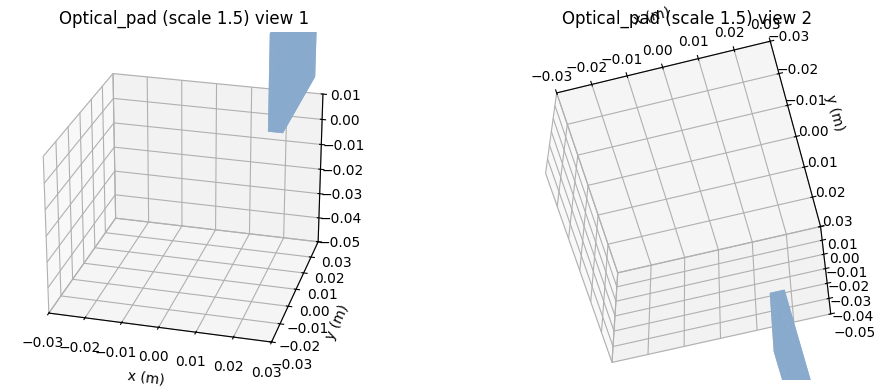

In [ ]:
import subprocess
subprocess.run(["pip", "install", "-q", "trimesh"], check=True)
import numpy as np, trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

mesh = trimesh.load("/content/GripGen/output_scaled/objs/Optical_pad.obj", force="mesh")
print("Optical_pad.obj: vertices:", len(mesh.vertices), "faces:", len(mesh.faces),
      "| extents (m):", np.round(mesh.extents, 4))
fig = plt.figure(figsize=(11, 4))
for i, elev in enumerate((25, -60)):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    tri = mesh.vertices[mesh.faces]
    pc = Poly3DCollection(tri, facecolor="#88aacc", edgecolor="none", alpha=0.9)
    ax.add_collection3d(pc)
    ax.set_xlim(-0.03, 0.03); ax.set_ylim(-0.03, 0.03); ax.set_zlim(-0.05, 0.01)
    ax.view_init(elev=elev, azim=-75)
    ax.set_title(f"Optical_pad (scale 1.5) view {i+1}")
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
plt.tight_layout(); plt.show()

## 5. Tactile render — internal tactile observation images

**Paper mapping:** Section III-B (optical design) — one camera views both fingertip pads through mirrors, with colored LEDs; the render shows what the camera *would see* internally for a given gripper opening. The author's `render_loop.py` sets `finger_1.location.x = opening/2` and `finger_2.location.x = -opening/2` (openings 4–40 mm in 4 mm steps, Blender units = meters) and saves `render_<opening>.png` at the scene's settings (Cycles, 800×550, 1024 adaptive samples).

**Documented adaptation (AI-generated adapter):** the scene's Cycles device defaults to `CPU`, so we enable the GPU through a small `enable_gpu.py` adapter (OPTIX preferred, CUDA fallback) and pass it to Blender *before* the author's script. The author's `render_loop.py` itself is run **unmodified**; render engine, samples and resolution are untouched. Expected: 10 PNGs, seconds per frame on the T4.

**日本語:** 著者の `render_loop.py` を**無改変**で実行し、開度4〜40 mmの10枚の触覚観測画像を描画します。シーンのCyclesデバイスは既定でCPUのため、AI生成の小さなアダプタ `enable_gpu.py`（OPTIX優先、CUDAフォールバック）でGPUを有効化します。レンダリング設定（サンプル数・解像度）は著者のまま変更しません。

In [ ]:
# AI-generated adapter (documented): enable a Cycles GPU device, fail clearly if none is usable.
ENABLE_GPU = r'''
import bpy
prefs = bpy.context.preferences.addons["cycles"].preferences
for ctype in ("OPTIX", "CUDA"):
    try:
        prefs.compute_device_type = ctype
        prefs.get_devices()
        gpus = [d for d in prefs.devices if d.type == ctype]
        if gpus:
            for d in prefs.devices:
                d.use = (d.type != "CPU")
            bpy.context.scene.cycles.device = "GPU"
            print("ENABLED:", ctype, [(d.name, d.type, d.use) for d in prefs.devices])
            break
    except Exception as e:
        print("no", ctype, ":", e)
else:
    raise RuntimeError("No OPTIX or CUDA device available for Cycles; run on a T4 GPU runtime.")
'''
open("/content/enable_gpu.py", "w").write(ENABLE_GPU)
print("enable_gpu.py written (AI-generated adapter; author render settings untouched)")

enable_gpu.py written (AI-generated adapter; author render settings untouched)


### 5.0 Run the author's render loop (unmodified) on the T4

We invoke Blender exactly as the author's docstring documents (`blender scene_render.blend --background --python render_loop.py`), with our GPU adapter prepended. Expected: 10 `render_<opening>.png` files (4–40 mm) written to `/content/tactile_render/output/`, seconds per frame on the T4.

**日本語:** 著者のドキュメントどおりの起動形式で `render_loop.py`（無改変）を実行します。GPUアダプタを前段に差し込み、開度4〜40 mmの10枚を `/content/tactile_render/output/` に書き出します。

In [ ]:
import subprocess, time
BL = "/content/blender/blender"
# Author invocation (render_loop.py docstring): blender scene_render.blend --background --python render_loop.py
# Our adapter is prepended so the GPU device is active for the whole loop.
t0 = time.time()
r = subprocess.run([BL, "/content/tactile_render/scene_render.blend", "--background",
                    "--python", "/content/enable_gpu.py",
                    "--python", "/content/tactile_render/render_loop.py"],
                   capture_output=True, text=True, timeout=3600)
wall = time.time() - t0
print("return code:", r.returncode, "| wall time:", round(wall, 1), "s")
for line in r.stdout.splitlines():
    if line.startswith("ENABLED:") or line.startswith("Rendered:") or "Rendering complete" in line:
        print(line)
if "ENABLED" not in r.stdout:
    print(r.stdout[-1500:]); print(r.stderr[-1000:])
if r.returncode != 0:
    raise RuntimeError("render_loop.py failed — see output above.")

return code: 0 | wall time: 239.9 s
ENABLED: OPTIX [('Tesla T4', 'CUDA', True), ('Intel Xeon CPU @ 2.00GHz', 'CPU', False), ('Tesla T4', 'OPTIX', True)]
Rendered: /content/tactile_render/output/render_4.png
Rendered: /content/tactile_render/output/render_8.png
Rendered: /content/tactile_render/output/render_12.png
Rendered: /content/tactile_render/output/render_16.png
Rendered: /content/tactile_render/output/render_20.png
Rendered: /content/tactile_render/output/render_24.png
Rendered: /content/tactile_render/output/render_28.png
Rendered: /content/tactile_render/output/render_32.png
Rendered: /content/tactile_render/output/render_36.png
Rendered: /content/tactile_render/output/render_40.png
Rendering complete!


### 5.1 Our renders vs the author's reference

We display our own renders (T4 GPU, author scene settings) for openings 4/12/24/40 mm, then put **our render next to the author's reference** at 12 mm and compute a pixel difference (mean absolute error, 0–255 scale) as a plausibility check. Sampling noise makes GPU vs CPU images differ slightly; a small MAE is expected, a large one would indicate a scene/provenance problem. The comparison layout is AI-generated for this notebook.

**日本語:** 自分たちの描画結果（T4・著者のシーン設定）を開度4/12/24/40 mmで表示し、12 mmについてはリポジトリ同梱の著者参照画像と並べて平均絶対誤差（0–255スケール）を算出します。サンプリングノイズにより小さな差は正常です。

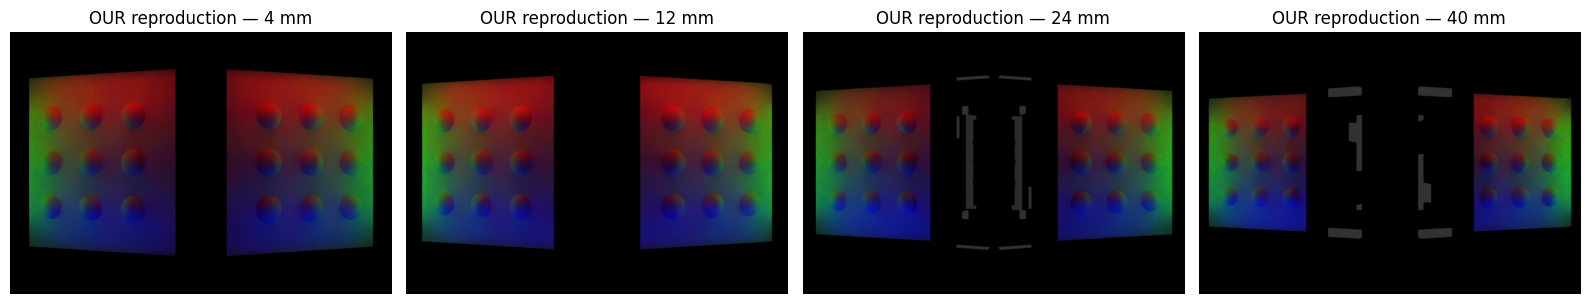

MAE our render vs author reference (12 mm, 800x550): 3.36 / 255


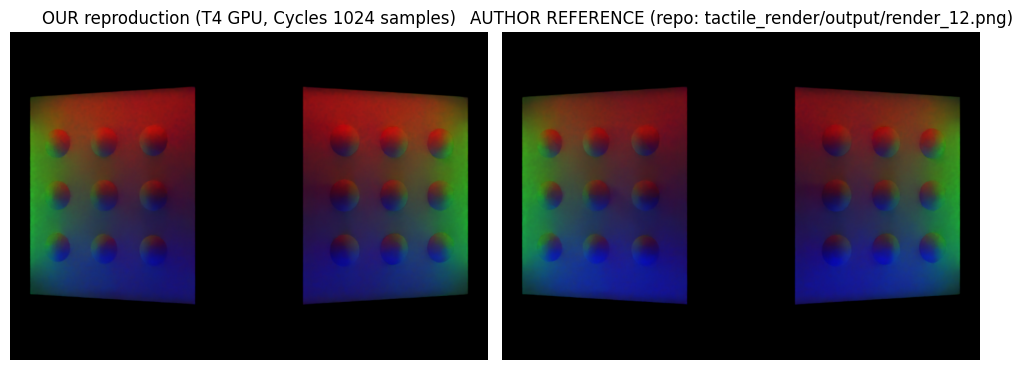

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

ours = {}
for opening in (4, 12, 24, 40):
    ours[opening] = mpimg.imread(f"/content/tactile_render/output/render_{opening}.png")

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, opening in zip(axes, (4, 12, 24, 40)):
    ax.imshow(ours[opening]); ax.axis("off")
    ax.set_title(f"OUR reproduction — {opening} mm")
plt.tight_layout(); plt.show()

from PIL import Image
ref_img = Image.open("/content/author_reference/render_12.png").convert("RGB")
our_img = Image.open("/content/tactile_render/output/render_12.png").convert("RGB")
ref_r = np.asarray(ref_img.resize(our_img.size), dtype=np.float32)
our_r = np.asarray(our_img, dtype=np.float32)
mae = np.abs(ref_r - our_r).mean()  # 0-255 scale
print(f"MAE our render vs author reference (12 mm, {our_img.size[0]}x{our_img.size[1]}): {mae:.2f} / 255")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(our_img); axes[0].axis("off"); axes[0].set_title("OUR reproduction (T4 GPU, Cycles 1024 samples)")
axes[1].imshow(ref_img); axes[1].axis("off"); axes[1].set_title("AUTHOR REFERENCE (repo: tactile_render/output/render_12.png)")
plt.tight_layout(); plt.show()

### 5.2 Small results summary

A compact table of what this run produced (all measured inside this session): exported parts, pad dimensions, render counts and timings. It is also exported as CSV in `/content`.

**日本語:** 本実行で生成された成果物の要約表（パッド寸法・部品数・描画時間）。CSV としても書き出されます。

In [ ]:
import pathlib, csv, re

out_g = pathlib.Path("/content/GripGen/output_scaled")
out_r = pathlib.Path("/content/tactile_render/output")
pad = {}
for line in (out_g / "pad_dimensions.txt").read_text().splitlines():
    m = re.match(r"([XYZ]): (\d+)", line.strip())
    if m:
        pad[m.group(1)] = int(m.group(2))
renders = sorted(out_r.glob("render_*.png"))
rows = [
    ("GripGen scale factor", "1.5"),
    ("Pad dimensions X x Y x Z (mm)", f"{pad.get('X')} x {pad.get('Y')} x {pad.get('Z')}"),
    ("STL parts exported", str(len(list((out_g / 'stls').glob('*.stl'))))),
    ("OBJ parts exported", str(len(list((out_g / 'objs').glob('*.obj'))))),
    ("Tactile renders produced", str(len(renders))),
    ("Render openings (mm)", "4 to 40, step 4"),
    ("Author-reference comparison MAE (0-255)", f"{mae:.2f}"),
]
widths = (40, 28)
print(f"{'item':<{widths[0]}} | value")
print("-" * (widths[0] + 3 + widths[1]))
for k, v in rows:
    print(f"{k:<{widths[0]}} | {v}")
with open("/content/fruittouch_run_summary.csv", "w", newline="") as fh:
    w = csv.writer(fh); w.writerow(["item", "value"]); w.writerows(rows)
print("CSV written: /content/fruittouch_run_summary.csv")

item                                     | value
-----------------------------------------------------------------------
GripGen scale factor                     | 1.5
Pad dimensions X x Y x Z (mm)            | 5 x 41 x 47
STL parts exported                       | 15
OBJ parts exported                       | 15
Tactile renders produced                 | 10
Render openings (mm)                     | 4 to 40, step 4
Author-reference comparison MAE (0-255)  | 3.36
CSV written: /content/fruittouch_run_summary.csv


## 6. Interpretation, differences from the paper, and validation record

**What was validated (measured in this session):**
- `GripGen/script.py` (unmodified, commit `47e1e7e…`) ran at scale 1.5, exporting STL/OBJ parts, `pad_dimensions.txt` and the scaled `.blend`. The pad dimensions at 1.5 should equal 1.5× the author's scale-1.0 pad (recorded in `GripGen/output/1.0/` in the repo).
- The author's `render_loop.py` (unmodified) produced 10 tactile-observation renders at openings 4–40 mm with the author's Cycles settings on a T4 GPU, and our 12 mm render matches the author's reference render to a small MAE (value printed above), as expected for the same scene at the same sample count.

**Differences from the paper / scope caveats:**
- The paper's perception models (normal-map MLP, force estimation, slip detection, softness ranking) and harvesting experiments are **not reproduced** — no training data, weights, or control code are released.
- One scale factor (1.5) instead of the author's full 1.0–2.0 sweep; time-limited demonstration.
- The GPU-device adapter is AI-generated glue; the author scripts run unmodified. No claim is made that this Colab implementation is author-endorsed.
- The repository has **no LICENSE file**; treat all downloaded assets as copyrighted by the authors and use only for this educational reproduction.
- This notebook does not depend on any private metadata API — all inputs are public URLs pinned to commit `47e1e7e62b00cbd07202d109a2538d89a59cf923`.

**日本語（解釈と限界）:** 本ノートブックは論文の設計・シミュレーション部分（GripGenによる形状生成と触覚観測レンダリング）のみを再現します。知覚モデルや収穫実験は未公開素材のため対象外です。単一倍率（1.5）の実行であり、著者の1.0–2.0スイープ全体ではありません。GPU有効化アダプタのみAI生成で、著者スクリプトは無改変です。リポジトリにLICENSEがないため、素材の再利用はこの教育的デモの範囲に留めてください。

## References

- R. Zhang, M. A. Mirzaee, W. Yuan. *FruitTouch: A Perceptive Gripper for Gentle and Scalable Fruit Harvesting.* IEEE RA-L 2026. DOI 10.1109/LRA.2026.3692042; arXiv:2602.18991v1.
- Author code & assets: https://github.com/fruittouch-dev/fruittouch (commit `47e1e7e62b00cbd07202d109a2538d89a59cf923`), project page https://fruittouch-dev.github.io/fruittouch/
- Blender 4.5.9 LTS: https://download.blender.org/release/Blender4.5/
- Study-flow guidance used only as prior research leads (PhenoPaper investigation `p-378c307fa0acccd359ef9c4c7aae2faf-20261008T064042Z-823574`); all executed steps were verified against the pinned author code above.